# Olink Plasma Proteomics Preprocessing
**Modality:** Plasma proteomics (Olink Explore)

Source: `data/raw/sound_life_all_olink.csv` (long; one row per sample x assay x panel)
Output: `data/processed/olink_baseline_wide.csv` (selected node block)
Interim: `data/interim/olink_full_pivot.csv` (full pivot; exploratory, not a BN input)
Manifest: `data/processed/feature_manifest.csv`
Selection evidence: `context/olink_panel_selection.md`

Reduces ~1,470 proteins to a **35-protein, literature-selected panel** (14 core + 21
extended). Every protein has an **independent, non-Sound-Life** immune-aging citation
(structurally flat prior: selection is external biology, never this dataset's own
variance/association structure). Value column: **`olink.NPX_norm`** (batch-normalized).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

from src.io import append_manifest, enforce_export_contract, write_processed
from src.load import load_csv
from src.qc import assert_no_duplicates, flag_missingness

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
INTERIM = Path("../data/interim")
FIGURES = Path("../figures/preprocessing")
for d in (PROCESSED, INTERIM, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

BASELINE_VISIT = "Flu Year 1 Day 0"
VALUE_COL = "olink.NPX_norm"   # batch-normalized NPX (not NPX_raw)
LOD_COL = "olink.LOD_norm"

# Fixed-panel priority resolves proteins measured on multiple panels (bridging
# controls IL6/TNF/CXCL8). Lower rank = higher priority. Never averaged: panels
# carry systematic NPX offsets, and a fixed panel ties each node to one real assay.
PANEL_PRIORITY = {"Inflammation": 0, "Cardiometabolic": 1, "Neurology": 2, "Oncology": 3}
BRIDGING = {"IL6", "TNF", "CXCL8"}   # measured on all 4 panels
PRIMARY_PANEL = "Inflammation"       # fixed choice for bridging proteins

LOD_GATE = 0.30        # disqualify a candidate if >30% of baseline samples below LOD
MISS_THRESHOLD = 0.20  # >20% missing => exclude_candidate flag (flag, never drop)

In [2]:
# --- Literature-selected panel (see context/olink_panel_selection.md) ---
# (protein, biological role, independent non-Sound-Life citation key)
CORE = [
    ("IL6",      "Master inflammaging cytokine; mortality predictor", "Ferrucci18; Bruunsgaard03; Coppe10"),
    ("TNF",      "Inflammaging cytokine; mortality predictor",        "Ferrucci18; Bruunsgaard03; Komosinska11"),
    ("CXCL8",    "SASP chemokine (IL-8)",                             "Coppe10"),
    ("CXCL9",    "#1 contributor to iAge inflammatory clock",         "Sayed21"),
    ("GDF15",    "Strongest age-associated plasma protein",           "Tanaka18; Lehallier19"),
    ("CCL11",    "'Aging factor' eotaxin",                            "Villeda11"),
    ("TNFRSF1A", "Soluble TNFR1 rises with age",                      "Komosinska11"),
    ("CD8A",     "CD8 T-cell immunosenescence",                       "Tarazona00"),
    ("GZMA",     "Cytotoxic effector accumulation with age",          "Tarazona00"),
    ("GZMB",     "Cytotoxic effector accumulation with age",          "Tarazona00"),
    ("KLRD1",    "NK-receptor (CD94) on senescent T cells",           "Tarazona00"),
    ("FGF21",    "Circulating FGF21 rises with age indep. body comp", "Hanks15"),
    ("CHI3L1",   "YKL-40 rises with age; mortality in octogenarians", "Johansen08"),
    ("IL18",     "Inflammasome/inflammaging; serum rises over age 65","Barbe14"),
]
EXTENDED = [
    ("CXCL10",   "IFN-gamma-induced chemokine axis (with CXCL9)",     "Sayed21; Tanaka18"),
    ("CXCL11",   "IFN-gamma-induced chemokine axis (with CXCL9)",     "Sayed21; Tanaka18"),
    ("IFNG",     "Th1 driver of CXCL9/10/11 axis",                    "Sayed21"),
    ("CCL2",     "Age-associated monocyte chemokine (MCP-1)",         "Tanaka18; Lehallier19"),
    ("CCL8",     "Age-associated chemokine pathway",                  "Tanaka18"),
    ("CCL3",     "Age-associated chemokine pathway",                  "Tanaka18"),
    ("CCL4",     "Age-associated chemokine pathway",                  "Tanaka18"),
    ("TNFRSF1B", "Soluble TNFR2 (paired receptor)",                   "Komosinska11; Ferrucci18"),
    ("MMP9",     "SASP protease",                                     "Coppe10"),
    ("MMP12",    "SASP protease",                                     "Coppe10"),
    ("IGFBP7",   "SASP factor",                                       "Coppe10"),
    ("VEGFA",    "SASP / angiogenic factor",                          "Coppe10"),
    ("IL10",     "Regulatory cytokine in inflammaging",               "Ferrucci18"),
    ("IL1RN",    "IL-1ra rises in older adults",                      "Barbe14; Ferrucci18"),
    ("IL7",      "T-cell homeostasis / immunosenescence",             "IL7rev"),
    ("IL15",     "T-cell homeostasis / immunosenescence",             "IL15rev"),
    ("PDCD1",    "Inhibitory checkpoint / immunosenescence",          "Salminen24"),
    ("LAG3",     "Inhibitory checkpoint / immunosenescence",          "Salminen24"),
    ("HAVCR2",   "Inhibitory checkpoint (TIM-3) / immunosenescence",  "Salminen24"),
    ("CD274",    "Checkpoint ligand (PD-L1) / immunosenescence",      "Salminen24"),
    ("LEP",      "Inflammaging adipokine (CAVEAT: adiposity-linked)", "Zoico13"),
]
PANEL = ([{"protein": p, "tier": "core", "role": r, "citation": c} for p, r, c in CORE]
         + [{"protein": p, "tier": "extended", "role": r, "citation": c} for p, r, c in EXTENDED])
SELECTED = [d["protein"] for d in PANEL]
print(f"Panel: {len(SELECTED)} proteins ({len(CORE)} core + {len(EXTENDED)} extended)")

Panel: 35 proteins (14 core + 21 extended)


## Stage 1 - Ingestion & Standardization

In [3]:
raw = load_csv(RAW / "sound_life_all_olink.csv")
print(f"raw shape:        {raw.shape}")
print(f"samples:          {raw['sample.sampleKitGuid'].nunique()}")
print(f"subjects:         {raw['subject.subjectGuid'].nunique()}")
print(f"assays:           {raw['olink.assay'].nunique()}")
print(f"panels:           {sorted(raw['olink.panel'].dropna().unique())}")
print("observation unit: one row per sample x assay x panel (long)")
raw[["sample.sampleKitGuid", "olink.panel", "olink.assay", VALUE_COL, LOD_COL]].head()

C:\Users\annaj\bayomics\src\load.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(


raw shape:        (1274064, 26)
samples:          867
subjects:         96


assays:           1472
panels:           ['Cardiometabolic', 'Inflammation', 'Neurology', 'Oncology']
observation unit: one row per sample x assay x panel (long)


,sample.sampleKitGuid,olink.panel,olink.assay,olink.NPX_norm,olink.LOD_norm
0,KT00361,Neurology,TNFRSF1B,0.1672,-6.3078
1,KT00361,Neurology,PAMR1,0.3073,-5.2385
2,KT00361,Neurology,IL7R,0.5881,-5.0161
3,KT00361,Neurology,CD177,NaN,NaN
4,KT00361,Neurology,PRTFDC1,1.9377,1.1751


## Stage 2 - Baseline Filtering

Filter to `sample.visitName == "Flu Year 1 Day 0"` (the cross-modality baseline anchor;
yields the same 92-sample baseline as the cell-type-frequency block).

**Note on `daysSinceFirstVisit`:** the plan equates baseline with `daysSinceFirstVisit == 0`,
but in this file they are *not* equivalent - `daysSinceFirstVisit` counts from each subject's
first-ever draw, which for some subjects is an earlier (e.g. Immune Variation) visit. So
`visitName` is the correct anchor and `daysSinceFirstVisit == 0` is *not* asserted.

In [4]:
baseline = raw[raw["sample.visitName"] == BASELINE_VISIT].copy()
n_baseline = baseline["sample.sampleKitGuid"].nunique()
print(f"baseline samples (visitName == '{BASELINE_VISIT}'): {n_baseline}")
print(f"baseline subjects: {baseline['subject.subjectGuid'].nunique()}")

days = baseline.drop_duplicates("sample.sampleKitGuid")["sample.daysSinceFirstVisit"]
print(f"\n{int((days == 0).sum())}/{n_baseline} baseline samples have daysSinceFirstVisit == 0.")
print("The rest have positive values because those subjects' first-ever draw predates their")
print("Flu Year 1 Day 0 visit (earlier Immune Variation visit). visitName is the anchor.")

# No duplicate (sample x assay x panel) rows expected; validates pivot aggfunc='first'.
assert_no_duplicates(baseline, key_cols=["sample.sampleKitGuid", "olink.assay", "olink.panel"])
print("\nno duplicate (sample x assay x panel) rows.")

baseline samples (visitName == 'Flu Year 1 Day 0'): 92
baseline subjects: 92

60/92 baseline samples have daysSinceFirstVisit == 0.
The rest have positive values because those subjects' first-ever draw predates their
Flu Year 1 Day 0 visit (earlier Immune Variation visit). visitName is the anchor.

no duplicate (sample x assay x panel) rows.


## Stage 3 - QC: LOD Audit, Batch Inspection, Missingness (no imputation)

- **LOD gate:** below-LOD values are left-censored noise-floor; a candidate is disqualified
  if `NPX_norm < LOD_norm` in >30% of baseline samples (applied at selection, Stage 5).
- **Batch/plate:** descriptive sanity-check only. `NPX_norm` is already batch-normalized, so
  nothing here is corrected or feeds selection.

assays >30% below LOD (best panel): 225
assays >50% below LOD (best panel): 158


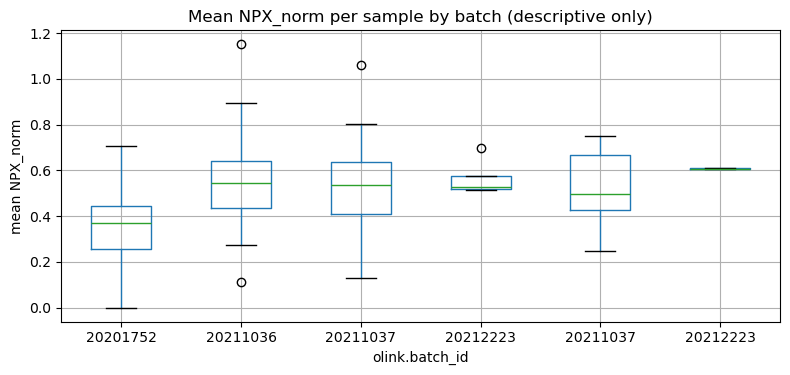

Batch figure is descriptive; NPX_norm is already batch-normalized -> no correction,
and batch structure never feeds protein selection.


In [5]:
baseline["below_lod"] = baseline[VALUE_COL] < baseline[LOD_COL]

# (a) Global LOD context (compare with cohort EDA: ~217 >30%, ~151 >50%)
per_assay_panel = (baseline.groupby(["olink.assay", "olink.panel"])["below_lod"]
                   .mean().reset_index(name="below_frac"))
best = (per_assay_panel.sort_values("below_frac")
        .drop_duplicates("olink.assay", keep="first"))
print(f"assays >30% below LOD (best panel): {(best['below_frac'] > LOD_GATE).sum()}")
print(f"assays >50% below LOD (best panel): {(best['below_frac'] > 0.50).sum()}")

# (b) Descriptive batch inspection (no correction applied)
per_sample_batch = (baseline.groupby(["sample.sampleKitGuid", "olink.batch_id"])[VALUE_COL]
                    .mean().reset_index())
fig, ax = plt.subplots(figsize=(8, 4))
per_sample_batch.boxplot(column=VALUE_COL, by="olink.batch_id", ax=ax)
ax.set_title("Mean NPX_norm per sample by batch (descriptive only)")
ax.set_xlabel("olink.batch_id"); ax.set_ylabel("mean NPX_norm")
plt.suptitle(""); plt.tight_layout()
plt.savefig(FIGURES / "olink_batch_inspection.png", dpi=150); plt.show()
print("Batch figure is descriptive; NPX_norm is already batch-normalized -> no correction,")
print("and batch structure never feeds protein selection.")

## Stage 4 - Fixed-Panel Resolution & Full Pivot (long -> wide)

For each (sample, assay), keep the value from the highest-priority panel present.
Single-panel proteins keep their only value; bridging proteins (IL6/TNF/CXCL8) resolve
to Inflammation. The full ~1,470-protein pivot is written to `data/interim/` for
exploration only - it is p >> n at n=92 and never a BN input.

In [6]:
baseline["panel_rank"] = baseline["olink.panel"].map(PANEL_PRIORITY)
assert baseline["panel_rank"].notna().all(), "unmapped panel in PANEL_PRIORITY"

chosen = (baseline.sort_values(["sample.sampleKitGuid", "olink.assay", "panel_rank"])
          .drop_duplicates(["sample.sampleKitGuid", "olink.assay"], keep="first"))

guid_map = (chosen[["sample.sampleKitGuid", "subject.subjectGuid"]].drop_duplicates()
            .set_index("sample.sampleKitGuid"))

full_wide = chosen.pivot_table(index="sample.sampleKitGuid", columns="olink.assay",
                               values=VALUE_COL, aggfunc="first")
full_wide.columns = [f"olink.{c}" for c in full_wide.columns]
full_wide = full_wide.join(guid_map).reset_index()
full_wide = full_wide[["subject.subjectGuid", "sample.sampleKitGuid"]
                      + [c for c in full_wide.columns if c.startswith("olink.")]]
full_wide.to_csv(INTERIM / "olink_full_pivot.csv", index=False)
print(f"full pivot: {full_wide.shape} -> {INTERIM / 'olink_full_pivot.csv'} (exploratory only)")

full pivot: (92, 1474) -> ..\data\interim\olink_full_pivot.csv (exploratory only)


## Stage 5 - Feature Selection (literature-driven, tiered)

Restrict to the 35-protein panel. Build the NPX block, per-value `_flag_belowLOD` for every
selected protein, and `_flag_panelfallback` for the 3 bridging proteins. Assert every
selected protein passes the >30% LOD gate on its chosen panel. Audit missingness; nothing
is dropped or imputed.

all 35 selected proteins pass the 30% LOD gate (max below-LOD = 0.098).
panel-fallback flags True (should be 0 at baseline): 0
selected proteins >20% missing (exclude_candidate): 0


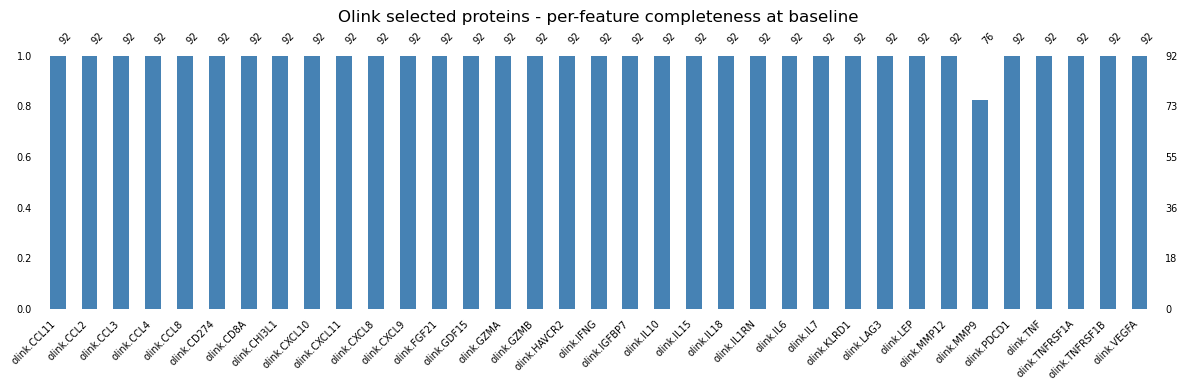

In [7]:
sel = chosen[chosen["olink.assay"].isin(SELECTED)].copy()
missing = [p for p in SELECTED if p not in set(sel["olink.assay"])]
assert not missing, f"selected proteins absent from data: {missing}"

# --- LOD gate assertion (chosen panel) ---
gate = sel.groupby("olink.assay")["below_lod"].mean()
failed = gate[gate > LOD_GATE]
assert failed.empty, f"selected proteins fail >{LOD_GATE:.0%} LOD gate:\n{failed}"
print(f"all {len(SELECTED)} selected proteins pass the {LOD_GATE:.0%} LOD gate "
      f"(max below-LOD = {gate.max():.3f}).")

# NPX value block
npx = sel.pivot_table(index="sample.sampleKitGuid", columns="olink.assay",
                      values=VALUE_COL, aggfunc="first")
npx.columns = [f"olink.{c}" for c in npx.columns]

# Per-value below-LOD flags (ride alongside the value; never drop/impute)
lodflag = sel.pivot_table(index="sample.sampleKitGuid", columns="olink.assay",
                          values="below_lod", aggfunc="first")
lodflag.columns = [f"olink.{c}_flag_belowLOD" for c in lodflag.columns]

# Panel-fallback flag: bridging proteins only (True if chosen panel != Inflammation)
sel["panelfallback"] = (sel["olink.assay"].isin(BRIDGING)
                        & (sel["olink.panel"] != PRIMARY_PANEL))
fb = (sel[sel["olink.assay"].isin(BRIDGING)]
      .pivot_table(index="sample.sampleKitGuid", columns="olink.assay",
                   values="panelfallback", aggfunc="first"))
fb.columns = [f"olink.{c}_flag_panelfallback" for c in fb.columns]
print(f"panel-fallback flags True (should be 0 at baseline): {int(fb.to_numpy().sum())}")

# --- Missingness audit on selected NPX ---
miss = flag_missingness(npx, threshold=MISS_THRESHOLD)
n_excl = int(miss["exclude_candidate"].sum())
print(f"selected proteins >{MISS_THRESHOLD:.0%} missing (exclude_candidate): {n_excl}")
if n_excl:
    print(miss[miss["exclude_candidate"]].to_string())
fig, ax = plt.subplots(figsize=(12, 4))
msno.bar(npx, ax=ax, fontsize=7, color="steelblue")
ax.set_title("Olink selected proteins - per-feature completeness at baseline")
plt.tight_layout(); plt.savefig(FIGURES / "olink_selected_missingness.png", dpi=150); plt.show()

In [8]:
# Assemble output: identifiers -> NPX values -> all flag columns last
npx_cols = [f"olink.{p}" for p in SELECTED]
flag_cols = [f"olink.{p}_flag_belowLOD" for p in SELECTED] + list(fb.columns)

wide = npx.join(guid_map).reset_index()
wide = wide.join(lodflag, on="sample.sampleKitGuid").join(fb, on="sample.sampleKitGuid")
wide = wide[["subject.subjectGuid", "sample.sampleKitGuid"] + npx_cols + flag_cols]

tiers = pd.Series([d["tier"] for d in PANEL]).value_counts().to_dict()
print(f"output shape: {wide.shape}  (NPX={len(npx_cols)}, flags={len(flag_cols)})")
print(f"tiers: {tiers}")
wide.head()

output shape: (92, 75)  (NPX=35, flags=38)
tiers: {'extended': 21, 'core': 14}


,subject.subjectGuid,sample.sampleKitGuid,olink.IL6,olink.TNF,olink.CXCL8,olink.CXCL9,olink.GDF15,olink.CCL11,olink.TNFRSF1A,olink.CD8A,...,olink.IL7_flag_belowLOD,olink.IL15_flag_belowLOD,olink.PDCD1_flag_belowLOD,olink.LAG3_flag_belowLOD,olink.HAVCR2_flag_belowLOD,olink.CD274_flag_belowLOD,olink.LEP_flag_belowLOD,olink.CXCL8_flag_panelfallback,olink.IL6_flag_panelfallback,olink.TNF_flag_panelfallback
0,BR1001,KT00001,-0.1194,0.8950,-0.7453,1.1116,-0.0682,-0.5730,0.3107,1.5163,...,False,False,False,False,False,False,False,False,False,False
1,BR1002,KT00002,0.1698,0.1151,-0.0586,-0.5304,-0.5356,-0.0960,0.1158,1.0258,...,False,False,False,False,False,False,False,False,False,False
2,BR1003,KT00003,0.3210,0.3728,0.1044,-0.7893,-0.5921,-1.2409,-0.0842,1.0714,...,False,False,False,False,False,False,False,False,False,False
3,BR1004,KT00004,1.3439,0.3532,0.4880,-0.4948,-0.2884,-0.1704,-0.1928,0.5490,...,False,False,False,False,False,False,False,False,False,False
4,BR1005,KT00006,0.3502,0.4732,-1.1860,0.5413,-0.7187,-0.4108,-0.2016,2.2960,...,False,False,False,False,False,False,False,False,False,False


## Stage 6 - Export & Manifest

In [9]:
enforce_export_contract(wide, prefix="olink.")
out = write_processed(wide, modality_name="olink", output_dir=str(PROCESSED))
print(f"written: {out}")

manifest_entries = []
for d in PANEL:
    p = d["protein"]
    panel_used = sel.loc[sel["olink.assay"] == p, "olink.panel"].iloc[0]
    manifest_entries.append({
        "feature_name": f"olink.{p}",
        "modality": "olink",
        "source_column": f"olink.NPX_norm (panel={panel_used})",
        "rationale": (f"[{d['tier'].upper()}] {d['role']}. "
                      f"Independent citation(s): {d['citation']}. "
                      f"Selected by external immune-aging biology (flat prior); "
                      f"passes >30% LOD gate. See context/olink_panel_selection.md."),
    })
append_manifest(manifest_entries, str(PROCESSED / "feature_manifest.csv"))
print(f"manifest entries appended: {len(manifest_entries)}")
pd.read_csv(PROCESSED / "feature_manifest.csv").query("modality == 'olink'").head()

written: ..\data\processed\olink_baseline_wide.csv
manifest entries appended: 35


,feature_name,modality,source_column,rationale
999,olink.IL6,olink,olink.NPX_norm (panel=Inflammation),[CORE] Master inflammaging cytokine; mortality...
1000,olink.TNF,olink,olink.NPX_norm (panel=Inflammation),[CORE] Inflammaging cytokine; mortality predic...
1001,olink.CXCL8,olink,olink.NPX_norm (panel=Inflammation),[CORE] SASP chemokine (IL-8). Independent cita...
1002,olink.CXCL9,olink,olink.NPX_norm (panel=Inflammation),[CORE] #1 contributor to iAge inflammatory clo...
1003,olink.GDF15,olink,olink.NPX_norm (panel=Cardiometabolic),[CORE] Strongest age-associated plasma protein...
